In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [2]:
adata.var_names

Index(['LINC01409', 'LINC01128', 'LINC00115', 'FAM41C', 'SAMD11', 'NOC2L',
       'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       ...
       'FUNDC2', 'CMC4', 'MTCP1', 'BRCC3', 'VBP1', 'TMLHE', 'SPRY3', 'VAMP7',
       'IL6RorST', 'TGFBR1or2'],
      dtype='object', length=13125)

In [3]:
#gl_ct1 = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
#gl_ct1 =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column
#gl_ct2 = ['PDGFB', 'STAT3','TGFBR1','TGFBR2','IL6R', 'IL6ST'] # All values from the first column

gl_ct1 =['PDGFB', 'STAT3', 'HES4', 'TGFB1']  # All values from the second column
gl_ct2 = ['PDGFRB','TGFBR1','TGFBR2'] # All values from the first column
# q0 -> PDGFB
# q1 -> STAT3
# q2 -> HIF1A | random -> HES4
# q3 -> TGFB1
# q4 -> PDGFRB
# q5 -> TGFBR1
# q6 -> TGFBR2
gl_all = gl_ct1 + gl_ct2

In [4]:
from scipy.sparse import issparse

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_ct1]
adata_ct2_co = adata[ict2, gl_ct2]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_ct2, knn=5, random_state=42) 

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_ct1]
adata_ct2_mo = adata[ict2, gl_ct2]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_ct2, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [6]:
import sys
import os
# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from qxct.encoding import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences


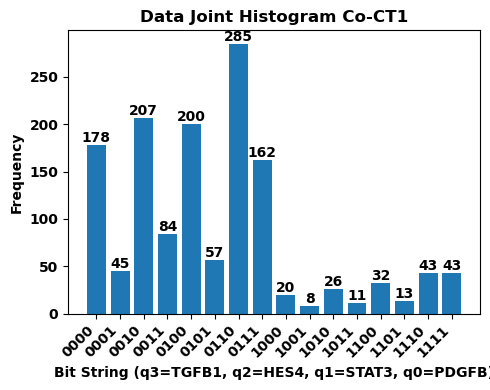

Joint Counts: Counter({'0110': 285, '0010': 207, '0100': 200, '0000': 178, '0111': 162, '0011': 84, '0101': 57, '0001': 45, '1110': 43, '1111': 43, '1100': 32, '1010': 26, '1000': 20, '1101': 13, '1011': 11, '1001': 8})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4), 
                     #filename = 'co_ct1_ov_can_hist_dist.svg',
                     title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

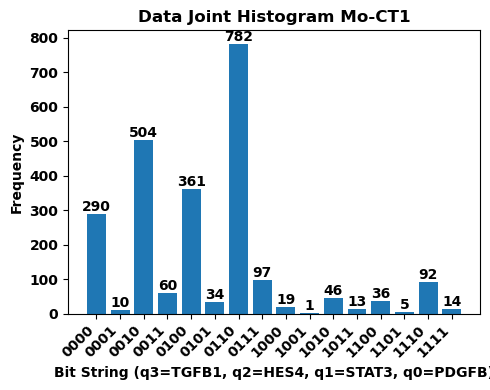

Joint Counts: Counter({'0110': 782, '0010': 504, '0100': 361, '0000': 290, '0111': 97, '1110': 92, '0011': 60, '1010': 46, '1100': 36, '0101': 34, '1000': 19, '1111': 14, '1011': 13, '0001': 10, '1101': 5, '1001': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4),
                     #filename = 'mo_ct1_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

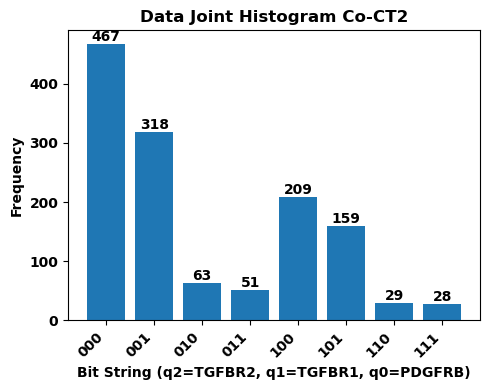

Joint Counts: Counter({'000': 467, '001': 318, '100': 209, '101': 159, '010': 63, '011': 51, '110': 29, '111': 28})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [9]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'co_ct2_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

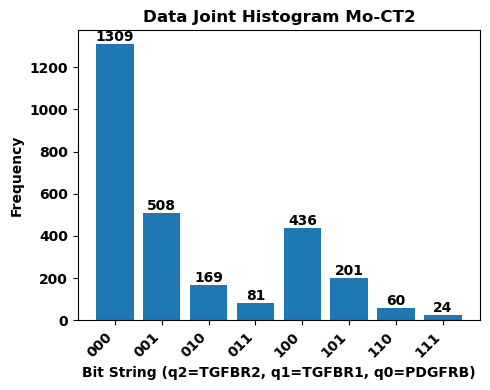

Joint Counts: Counter({'000': 1309, '001': 508, '100': 436, '101': 201, '010': 169, '011': 81, '110': 60, '111': 24})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [10]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'mo_ct1_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [11]:
from qxct.circuits import vector_normalize_dictionary_values, build_initial_state_circuit
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)
# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)
print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set CT1 MO (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set CT2 MO (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set CT1 CO (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set CT2 CO (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = build_initial_state_circuit(normalized_joint_counts_ct1_mo)
circ2 = build_initial_state_circuit(normalized_joint_counts_ct2_mo)


--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0110': 782, '0010': 504, '0100': 361, '0000': 290, '0111': 97, '1110': 92, '0011': 60, '1010': 46, '1100': 36, '0101': 34, '1000': 19, '1111': 14, '1011': 13, '0001': 10, '1101': 5, '1001': 1})
State Set CT2 MO: Counter({'000': 1309, '001': 508, '100': 436, '101': 201, '010': 169, '011': 81, '110': 60, '111': 24})
Interacted State Set CT1 CO: Counter({'0110': 285, '0010': 207, '0100': 200, '0000': 178, '0111': 162, '0011': 84, '0101': 57, '0001': 45, '1110': 43, '1111': 43, '1100': 32, '1010': 26, '1000': 20, '1101': 13, '1011': 11, '1001': 8})
Interacted State Set CT2 CO: Counter({'000': 467, '001': 318, '100': 209, '101': 159, '010': 63, '011': 51, '110': 29, '111': 28})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set CT1 MO (Vector Norm): {'0000': 0.2756467196255637, '0010': 0.47905498859063483, '0100': 0.3431326406373396, '0011': 0.05703035578459938, '0110': 0.7432956370592787, '0111': 0.092199075

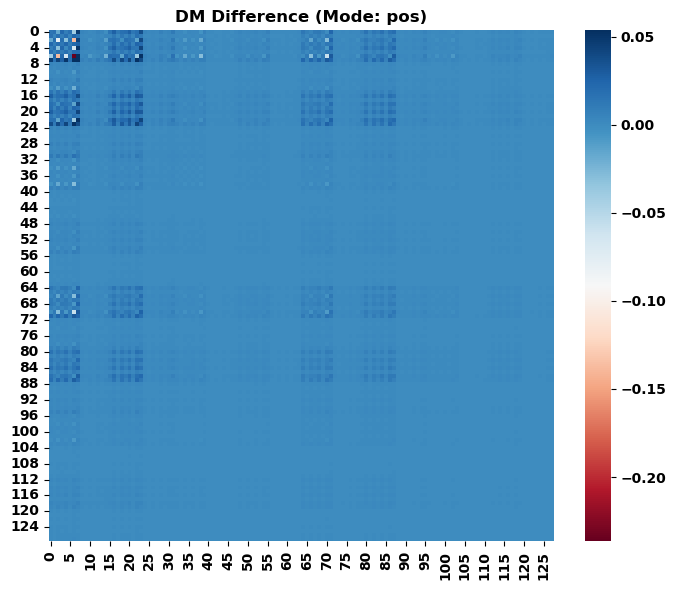


--- CNOT Analysis (pos) ---
Max Signal: 0.0535
Candidates Found: 30 / 42
------------------------------

{'max_element': 0.05354632393279451, 'min_element': -0.23653275593611303, 'abs_average': 0.0014000468909010984, 'relevant_avg': 0.001308547127273513}


In [12]:
from qxct.circuits import find_cnot_candidates_from_state_diff
thresh = 0.01 # 0.02
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, search_mode="pos" , 
    verbose_print = True)
print(stats)



--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


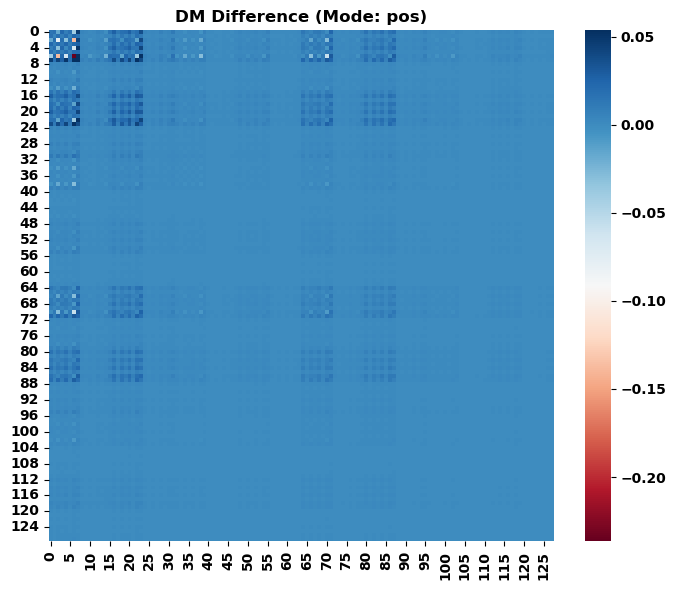


--- CNOT Analysis (pos) ---
Max Signal: 0.0535
Candidates Found: 30 / 42
------------------------------

Number of initial CNOT candidates: 30
Initial KL-divergence: 0.337730

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 0.324192 ---
   - Single Insertion Phase: Added (1, 4) at index 0. New KL: 0.244428
  [Phase 1] Added Single: (1, 4) | New KL: 0.244428
  [Phase 2] Added Pair: ((0, 1), (4, 0)) | New KL: 0.114150

--- Iteration 2 | Current KL: 0.114150 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 525.20s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(1, 4), (0, 1), (4, 0)]
KL sum after addition: 0.114150

Total search time: 525.69 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[1] -> q[4]
  q[0] -> q[1]
  q[4] -> q[0]
With minimum combined KL Divergence: 0.114150

--- Final Optimized Circuit ---
              »
         q_0: »
              »
         q_1: »
              »
         q

In [13]:
from qxct.circuits import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, apply_entanglement_topology
np.random.seed(42) 
print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    search_mode= "pos",
    nchoose=2,
    kl_tol = 0.05
)
print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")
    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = apply_entanglement_topology(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = apply_entanglement_topology(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")



--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0111': 709, '0000': 327, '0110': 2091, '0010': 870, '0001': 30, '0011': 309, '0100': 551, '1011': 1, '1100': 3, '1010': 8, '0101': 74, '1000': 2, '1110': 19, '1111': 6}
Counts for c_measure2: {'001': 1923, '000': 2473, '101': 238, '100': 285, '011': 34, '010': 38, '110': 5, '111': 4}


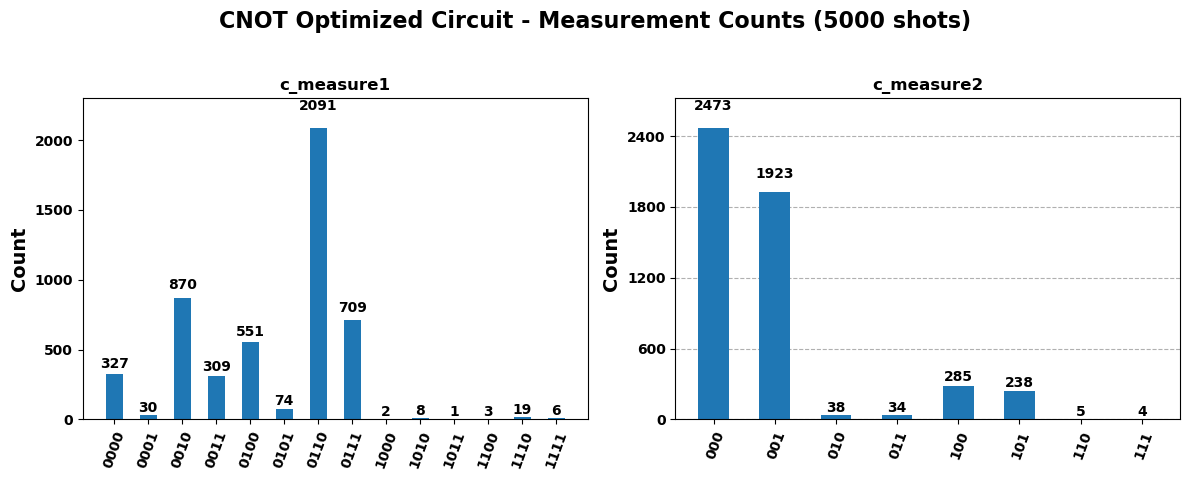

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


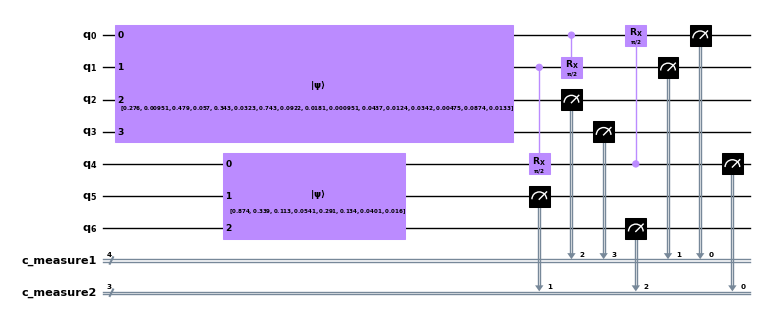

In [14]:
from qxct.circuits import plot_measurement_histograms
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5 )


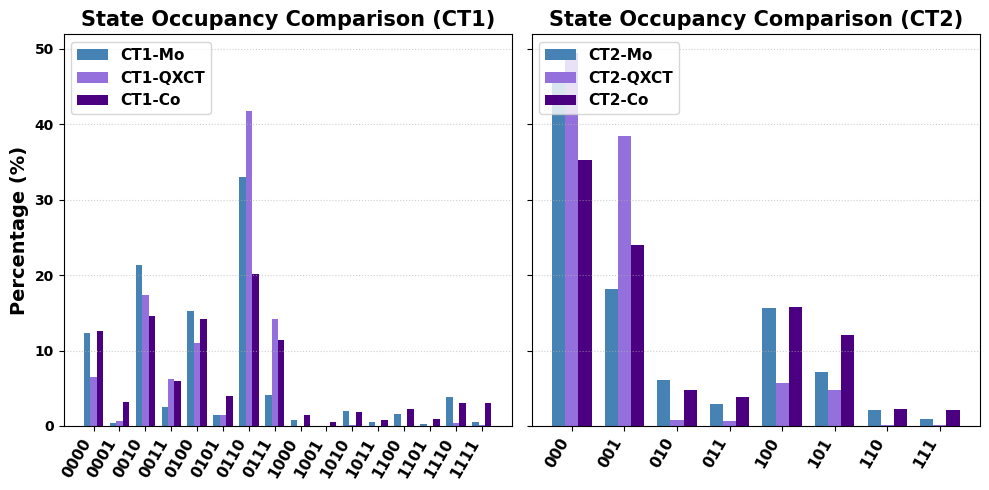

In [15]:
from qxct.encoding import normalize_counts
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (3 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.2370', '1.3334', '1.6910']
CRX Angle Optimization took: 10.09 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.2370', '1.3334', '1.6910']
  Minimum Combined KL Divergence with Optimized CRX: 0.091004


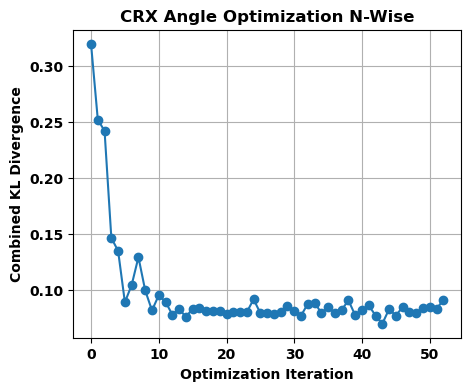


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                          ├»
«              │                                                                                                                                                           │»
«         q_1: ┤1                                                                                                               

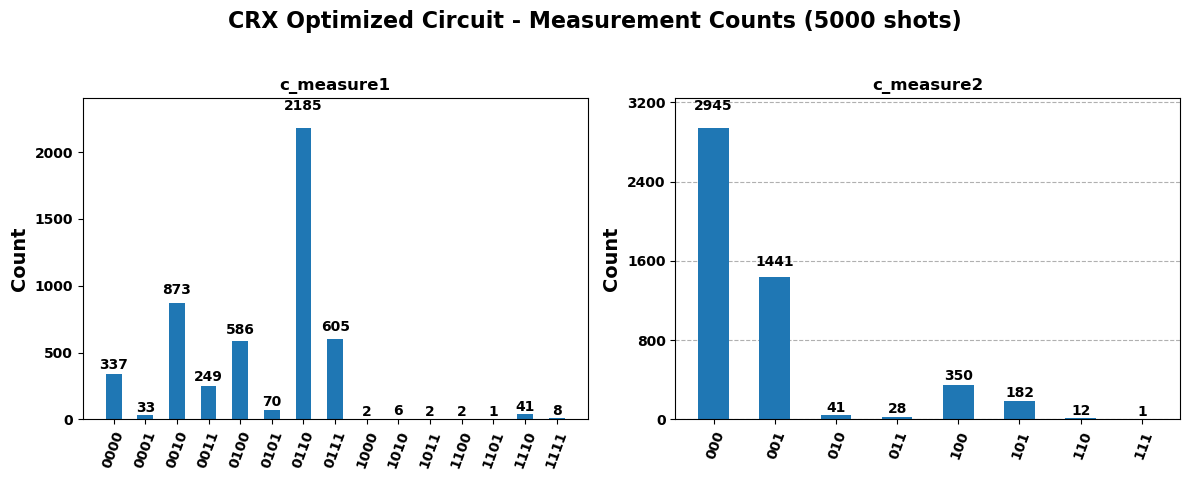

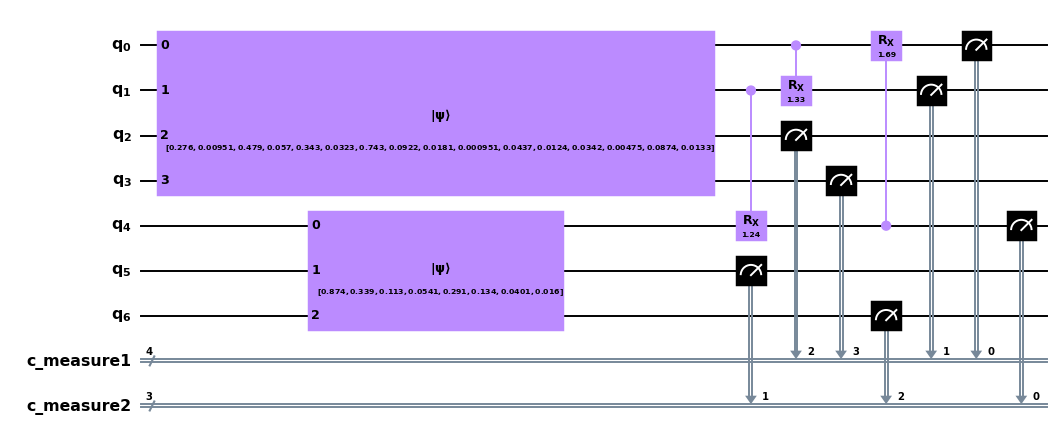

In [16]:
from qxct.circuits import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*0/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)
print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")
# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(5, 4))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization N-Wise')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    plt.savefig('optimization_history_sim_nwise_ov_can.svg', format='svg')
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory
# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7, filename="optimized_circ_nwise_ov_can.svg")


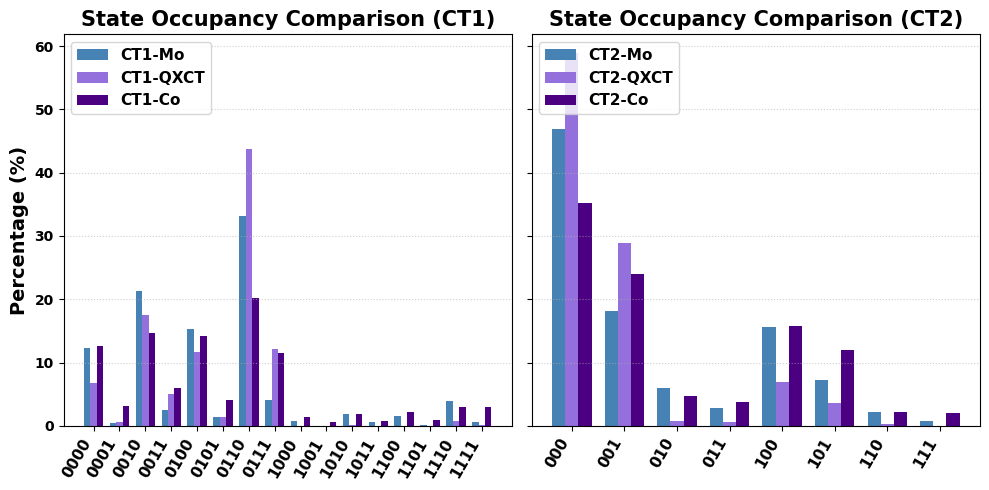

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt_nwise_hist_ov_can.svg')
plt.show()

In [ ]:
from qxct.circuits import analyze_and_summarize_network
# ==========================================================
# --- HOW TO USE IT (This is the only call you need) ---
# ==========================================================
# After you have run your angle optimization and have the final results.
# Assuming your results are stored in these variables:
# - best_cnot_sequence (the final topology)
# - optimized_crx_angles (the final angles)
# - gl_all (your list of gene names)
# - circ1, circ2 (your initial state circuits)
# - normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co (target distributions)
# Call the single, all-in-one analysis function
contribution_df, hub_dict, gene_set = analyze_and_summarize_network(
    circ1=circ1,
    circ2=circ2,
    topology=best_cnot_sequence,
    angles=optimized_crx_angles,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    gene_list=gl_all,
    nshots=5000
)
# Now you can work with the returned objects
# For example, to find the most impactful gate:
if not contribution_df.empty:
    most_impactful_gate = contribution_df.loc[contribution_df['KL Change'].idxmin()]
    print("\n--- Most Impactful Single Gate Addition ---")
    print(most_impactful_gate)

# --- Save results ---
from qxct.circuits import save_results
save_results(
    path="results/qxct_run",
    cnot_sequence=best_cnot_sequence,
    crx_angles=optimized_crx_angles,
    gene_list=gl_all,
    contribution_df=contribution_df,
    metadata={"nshots": 5000}
)



--- Comprehensive Interaction Network Analysis & Summary ---

--- Gate Contribution Analysis (Ablation Study) ---
   Step         Interaction CRX Angle (rad) KL Divergence KL Change Cumulative KL Reduction % Contribution CRX Angle (deg)
0     0  Baseline (0 gates)             nan        0.3284    0.0000                  0.0000          0.00%            nan°
1     1     STAT3 -> PDGFRB          1.2370        0.2433   -0.0851                 -0.0851         25.92%          70.87°
2     2      PDGFB -> STAT3          1.3334        0.2253   -0.0180                 -0.1031          5.49%          76.40°
3     3     PDGFRB -> PDGFB          1.6910        0.0828   -0.1424                 -0.2455         43.37%          96.89°

--- Hub-based Interaction Summary ---
Gene 'PDGFB' interacts with: STAT3
Gene 'PDGFRB' interacts with: PDGFB
Gene 'STAT3' interacts with: PDGFRB

--- Full Set of Interacting Genes ---
['PDGFB', 'PDGFRB', 'STAT3']

--- Most Impactful Single Gate Addition ---
Step       

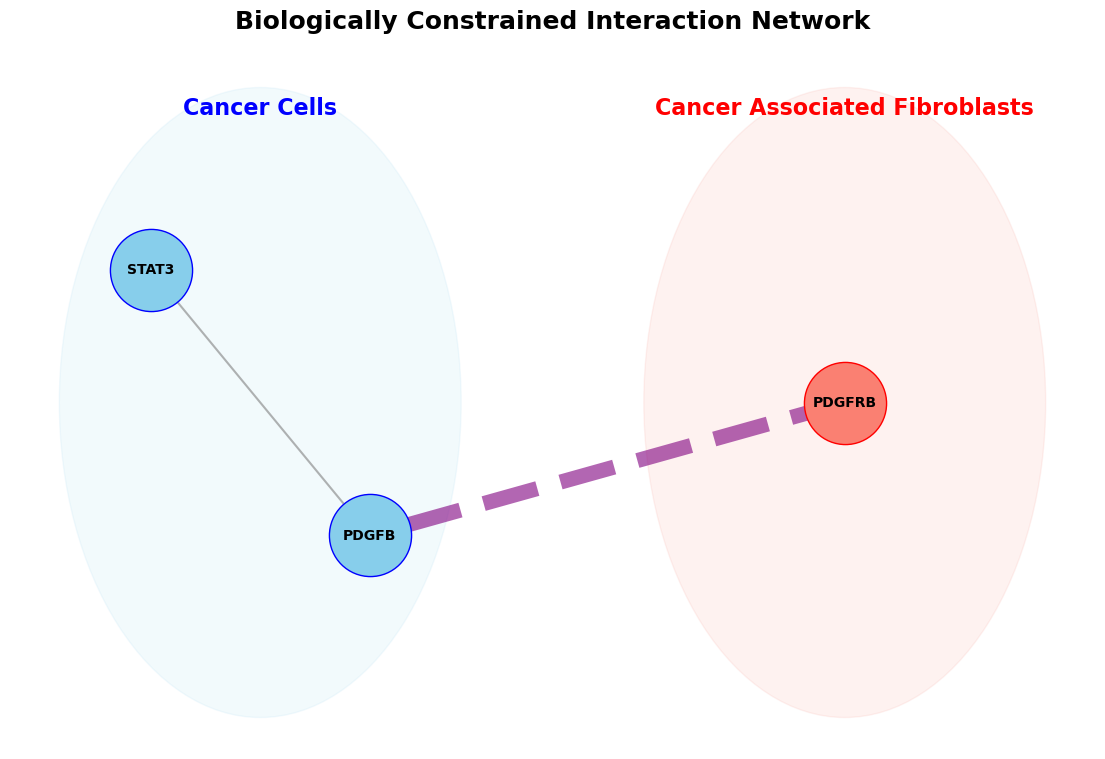

In [21]:
from qxct.circuits import plot_quantum_relay_network
# ==========================================================
# --- HOW TO USE IT (Now simpler and more direct) ---
# ==========================================================
# 1. You have already run this to get your final results:
# contribution_df, hub_dict, gene_set = analyze_and_summarize_network(...)
#
# The essential results needed for plotting are:
# - best_cnot_sequence (the topology)
# - gl_all (the master gene list)
# 2. Define your gene lists for each cell type and the valid L-R pairs
valid_lr_pairs = [('PDGFB', 'PDGFRB'), ('TGFB1', 'TGFBR1'), ('TGFB1', 'TGFBR2')]
# 3. Call the plotting function with only the necessary inputs
plot_quantum_relay_network(
    topology=best_cnot_sequence, # The raw topology result
    gene_list=gl_all,             # The master gene list
    gl_ct1=gl_ct1,
    gl_ct2=gl_ct2,
    contribution_df=contribution_df,
    ct1_name="Cancer Cells",
    ct2_name="Cancer Associated Fibroblasts",
    valid_lr_pairs=valid_lr_pairs,
    title="Biologically Constrained Interaction Network",
    fname="network_ang_opt_nwise_ov_can.svg"
)

# --- Save results ---
from qxct.circuits import save_results
save_results(
    path="results/qxct_run",
    cnot_sequence=best_cnot_sequence,
    crx_angles=optimized_crx_angles,
    gene_list=gl_all,
    contribution_df=contribution_df,
    metadata={"nshots": 5000}
)



--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


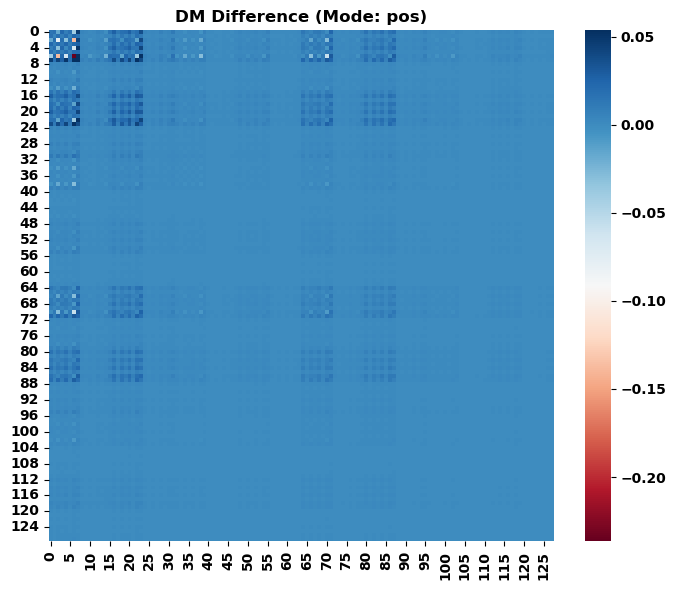


--- CNOT Analysis (pos) ---
Max Signal: 0.0535
Candidates Found: 30 / 42
------------------------------

Initial KL divergence (baseline): 0.319453

--- Starting Epoch 1/30 (Addition) with CNOT: (0, 4) (KL: 0.307576) ---
    --> Found a better KL on this path: 0.209637 at depth 2 with added CNOT (4, 0)
    --> Found a better KL on this path: 0.130506 at depth 3 with added CNOT (2, 4)
    --> Found a better KL on this path: 0.113072 at depth 4 with added CNOT (6, 1)
    --> Found a better KL on this path: 0.088909 at depth 5 with added CNOT (0, 6)
    --> Found a better KL on this path: 0.087843 at depth 6 with added CNOT (3, 0)
  Epoch 1 best KL Sum: 0.087843
  --> Epoch 1 found a new overall best KL Sum: 0.087843

--- Starting Greedy CNOT Removal Search on Best Found Sequence ---
  Starting removal search with 6 CNOTs (KL Sum: 0.087843)
  No CNOT removal improved the score. Stopping removal search.

--- Starting Epoch 2/30 (Addition) with CNOT: (3, 2) (KL: 0.326437) ---
  Skipping ep

In [22]:
from qxct.circuits import find_best_cnot_sequence_multi_epoch
np.random.seed(42) 
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)
n_epochs = 50
min_greedy_depth = 20
best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    kl_tol = 0.05
)
print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")
    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = apply_entanglement_topology(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = apply_entanglement_topology(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")



--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0110': 1861, '0010': 838, '0100': 706, '0111': 637, '0101': 187, '0011': 258, '0000': 386, '0001': 62, '1110': 27, '1100': 11, '1111': 11, '1010': 10, '1011': 2, '1101': 1, '1000': 3}
Counts for c_measure2: {'000': 2690, '001': 1314, '100': 478, '101': 429, '010': 43, '110': 14, '111': 6, '011': 26}


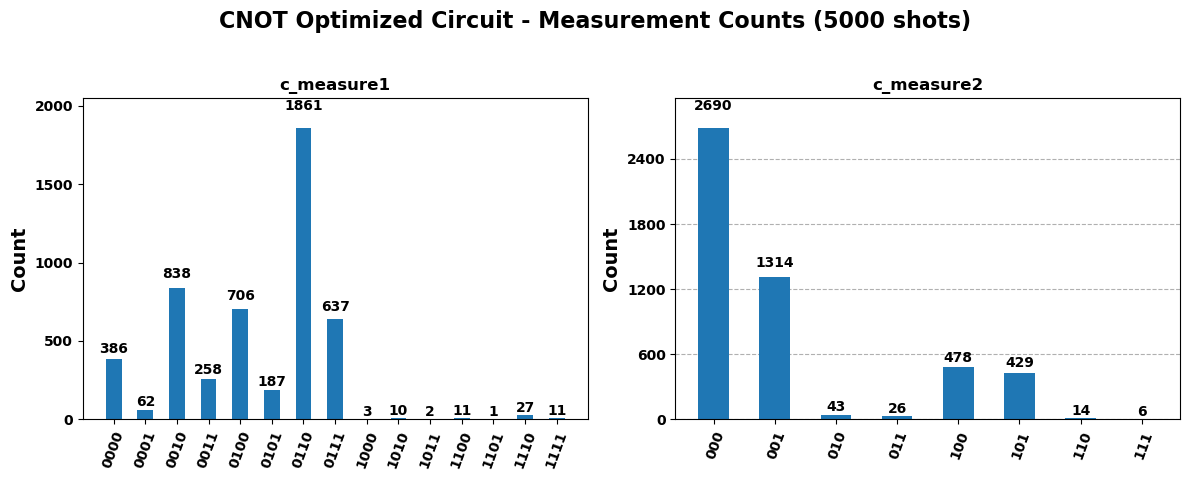

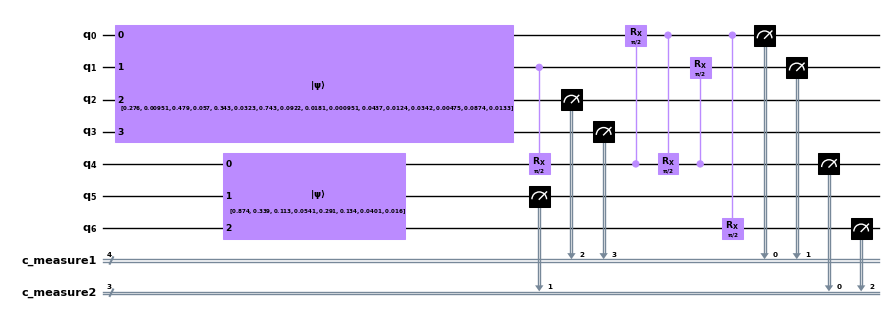

In [23]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

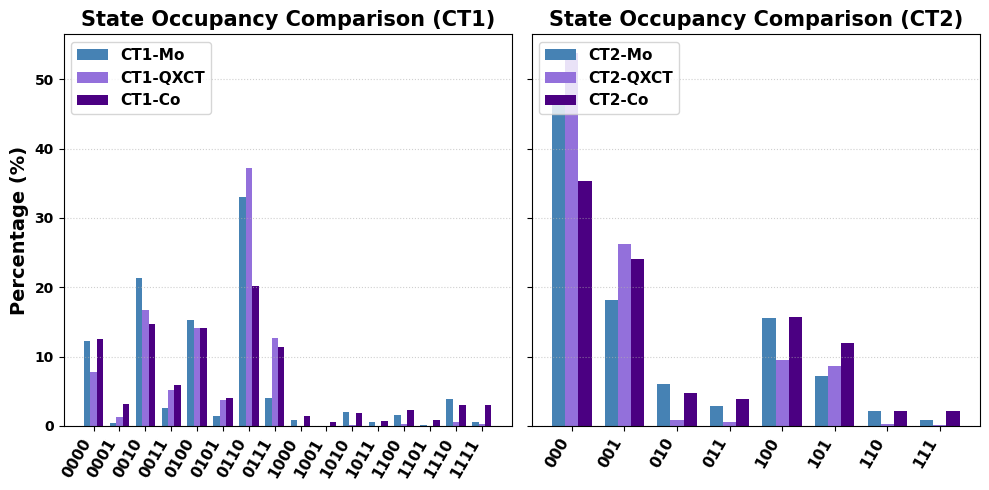

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison_multi_epoch_hist_ov_can.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (5 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.3748', '1.4373', '1.0914', '0.0000', '0.0001']
CRX Angle Optimization took: 15.26 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.3748', '1.4373', '1.0914', '0.0000', '0.0001']
  Minimum Combined KL Divergence with Optimized CRX: 0.076285


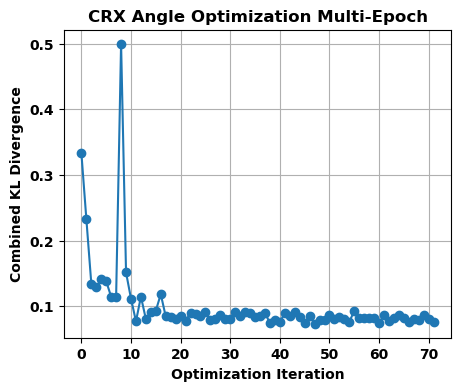


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                          ├»
«              │                                                                                                                                                           │»
«         q_1: ┤1                                                                                                               

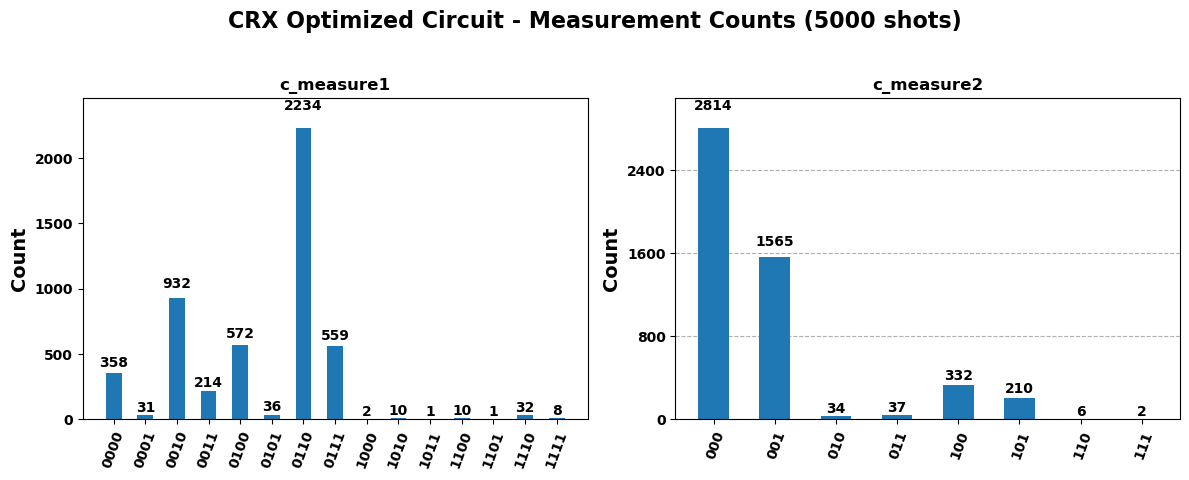

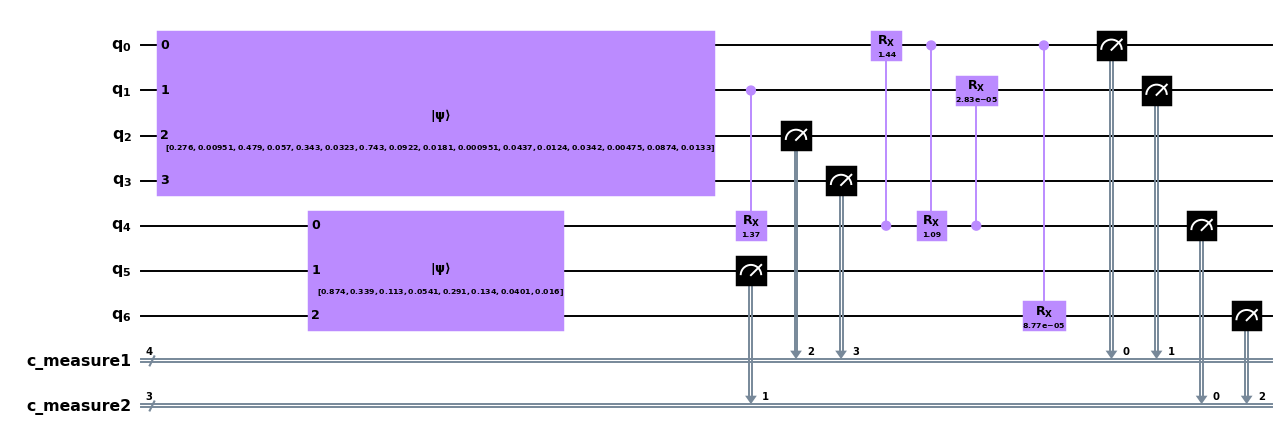

In [25]:
from qxct.circuits import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*0/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)
print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")
# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(5, 4))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization Multi-Epoch')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    plt.savefig('optimization_history_sim_multi_epoch_ov_can.svg', format='svg')
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory
# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7, filename="optimized_circ_multi_epoch_ov_can.svg")


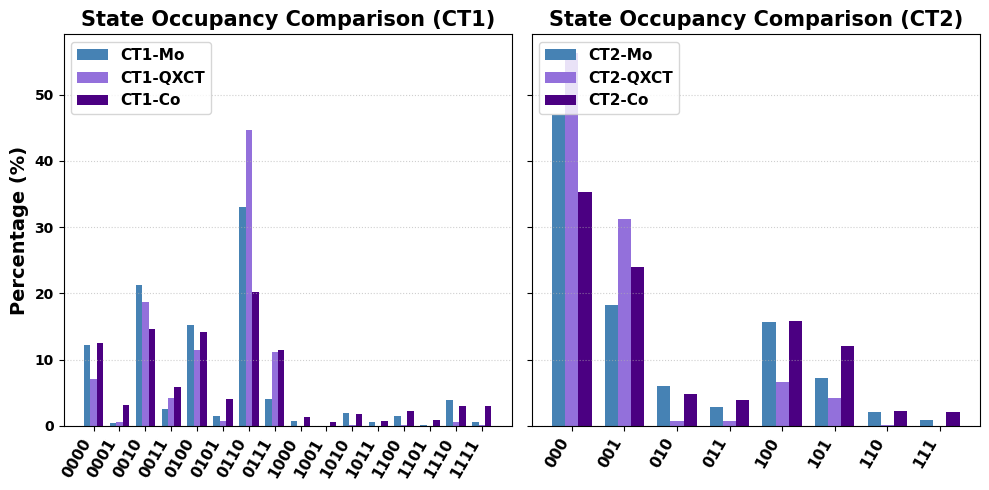

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt_multi_epoch_hist_ov_can.svg')
plt.show()

In [27]:
from qxct.circuits import analyze_and_summarize_network
# ==========================================================
# --- HOW TO USE IT (This is the only call you need) ---
# ==========================================================
# After you have run your angle optimization and have the final results.
# Assuming your results are stored in these variables:
# - best_cnot_sequence (the final topology)
# - optimized_crx_angles (the final angles)
# - gl_all (your list of gene names)
# - circ1, circ2 (your initial state circuits)
# - normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co (target distributions)
# Call the single, all-in-one analysis function
contribution_df, hub_dict, gene_set = analyze_and_summarize_network(
    circ1=circ1,
    circ2=circ2,
    topology=best_cnot_sequence,
    angles=optimized_crx_angles,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    gene_list=gl_all,
    nshots=5000
)
# Now you can work with the returned objects
# For example, to find the most impactful gate:
if not contribution_df.empty:
    most_impactful_gate = contribution_df.loc[contribution_df['KL Change'].idxmin()]
    print("\n--- Most Impactful Single Gate Addition ---")
    print(most_impactful_gate)

# --- Save results ---
from qxct.circuits import save_results
save_results(
    path="results/qxct_run",
    cnot_sequence=best_cnot_sequence,
    crx_angles=optimized_crx_angles,
    gene_list=gl_all,
    contribution_df=contribution_df,
    metadata={"nshots": 5000}
)



--- Comprehensive Interaction Network Analysis & Summary ---

--- Gate Contribution Analysis (Ablation Study) ---
   Step         Interaction CRX Angle (rad) KL Divergence KL Change Cumulative KL Reduction % Contribution CRX Angle (deg)
0     0  Baseline (0 gates)             nan        0.3241    0.0000                  0.0000          0.00%            nan°
1     1     STAT3 -> PDGFRB          1.3748        0.2330   -0.0911                 -0.0911         28.12%          78.77°
2     2     PDGFRB -> PDGFB          1.4373        0.0967   -0.1363                 -0.2274         42.05%          82.35°
3     3     PDGFB -> PDGFRB          1.0914        0.0833   -0.0134                 -0.2408          4.13%          62.53°
4     4     PDGFRB -> STAT3          0.0000        0.0874    0.0041                 -0.2367          1.26%           0.00°
5     5     PDGFB -> TGFBR2          0.0001        0.0722   -0.0152                 -0.2519          4.69%           0.01°

--- Hub-based Interacti

Figure saved as network_ang_opt_multi_epoch_ov_can.svg


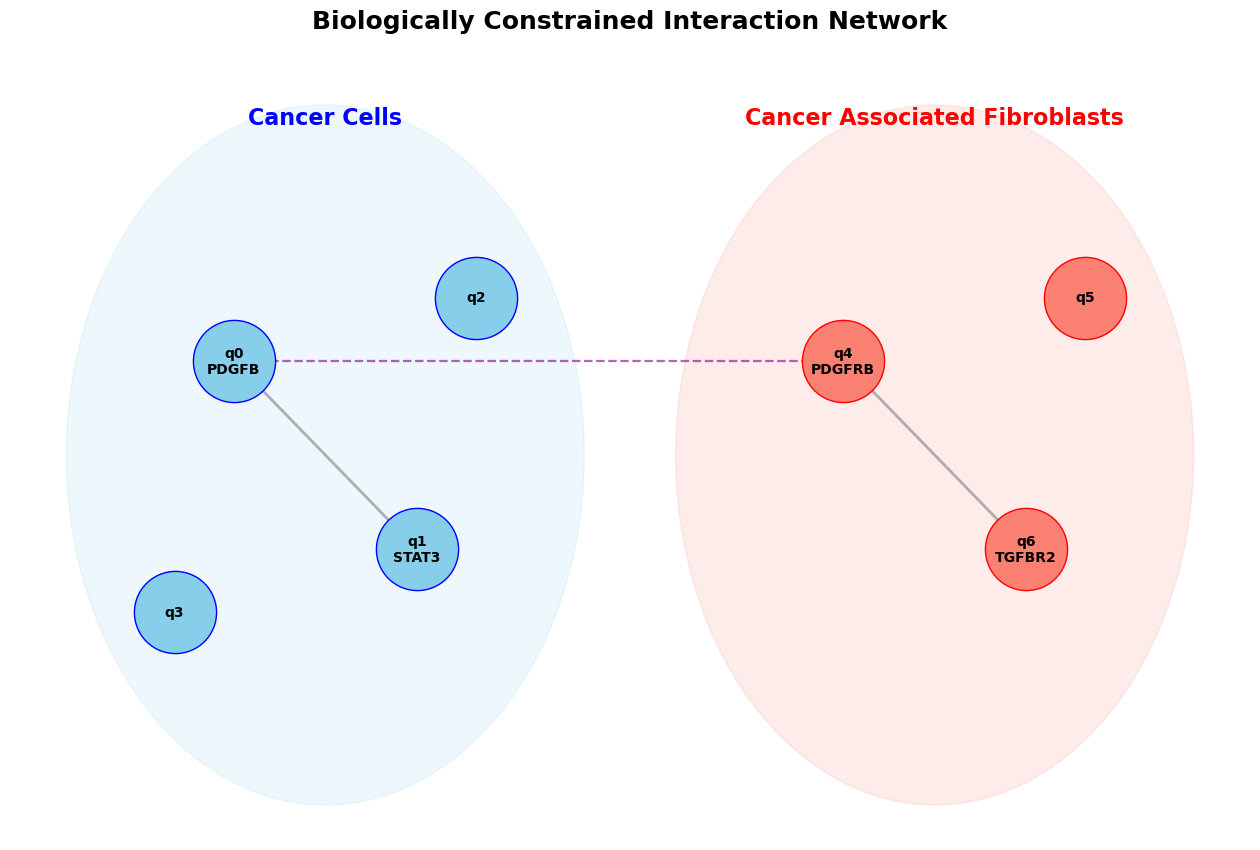

In [ ]:
from qxct.circuits import plot_quantum_relay_network
# ==========================================================
# --- HOW TO USE IT (Now simpler and more direct) ---
# ==========================================================
# 1. You have already run this to get your final results:
# contribution_df, hub_dict, gene_set = analyze_and_summarize_network(...)
#
# The essential results needed for plotting are:
# - best_cnot_sequence (the topology)
# - gl_all (the master gene list)
valid_lr_pairs = [('PDGFB', 'PDGFRB'), ('TGFB1', 'TGFBR1'), ('TGFB1', 'TGFBR2')]
# 3. Call the plotting function with only the necessary inputs
plot_quantum_relay_network(
    topology=best_cnot_sequence, # The raw topology result
    gene_list=gl_all,             # The master gene list
    gl_ct1=gl_ct1,
    gl_ct2=gl_ct2,
    contribution_df = contribution_df,
    ct1_name="Cancer Cells",
    ct2_name="Cancer Associated Fibroblasts",
    valid_lr_pairs=valid_lr_pairs,
    title="Biologically Constrained Interaction Network", 
    fname="network_ang_opt_multi_epoch_ov_can.svg"
)

# --- Save results ---
from qxct.circuits import save_results
save_results(
    path="results/qxct_run",
    cnot_sequence=best_cnot_sequence,
    crx_angles=optimized_crx_angles,
    gene_list=gl_all,
    contribution_df=contribution_df,
    metadata={"nshots": 5000}
)



--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


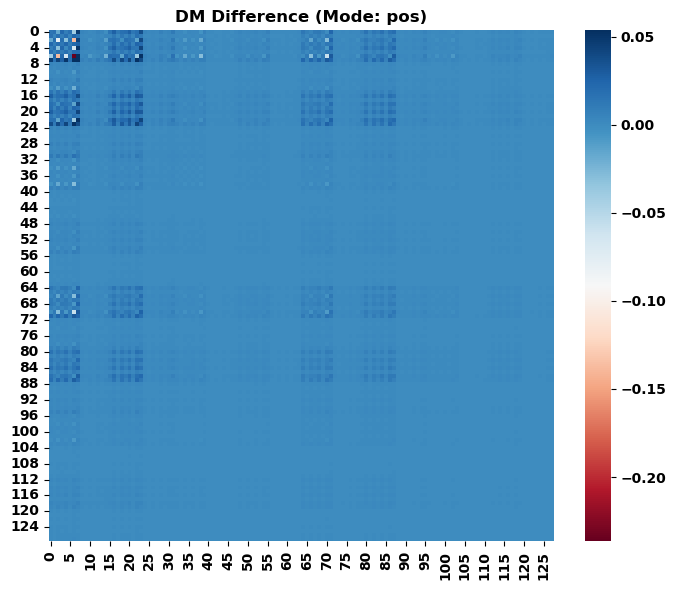


--- CNOT Analysis (pos) ---
Max Signal: 0.0535
Candidates Found: 30 / 42
------------------------------

Initial KL Divergence (no CNOTs): 0.334271

--- Building KL Divergence Matrix (30x30) ---
Calculating KL for single CNOTs (diagonal elements)...


In [ ]:
from qxct.circuits import build_kl_divergence_matrix_interaction
thresh = 0.01
np.random.seed(42) 
print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    search_mode= "pos",
    include_single_cnot_kl=True
)


In [26]:
from qxct.circuits import kl_to_qubo_matrix
# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)


In [27]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-0.31655470748517645
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIZIIIIIIIIIIIIIZ', 'IIIIIIIIIII

In [28]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_33576\2260493373.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


Starting optimization with method: COBYLA
Iteration 0: Current cost: -0.00877327207339849
Iteration 20: Current cost: 0.009404831754180025
Iteration 40: Current cost: -0.01977827778511311
Iteration 60: Current cost: -0.01834473205560882
Iteration 80: Current cost: 0.01494592202991849
Iteration 100: Current cost: 0.0003571953329317458
Iteration 200: Current cost: 0.044085988256562625

Optimization Result:
 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -0.06026607758733893
       x: [ 2.571e+00  2.571e+00 ...  1.571e+00  1.571e+00]
    nfev: 200
   maxcv: 0.0

Final Energy: -0.06026607758733893

Optimized Full Parameters:
  θ[0]: 2.5707963267948966
  θ[1]: 2.5707963267948966
  θ[2]: 1.5707963267948966
  θ[3]: 1.5707963267948966
  θ[4]: 2.5707963267948966
  θ[5]: 1.5707963267948966
  θ[6]: 1.5707963267948966
  θ[7]: 1.5707963267948966
  θ[8]: 1.5707963267948966
  θ[9]: 1.5707963267948966
  θ[10]: 1.5707963267948966
  θ[11]: 1.5707

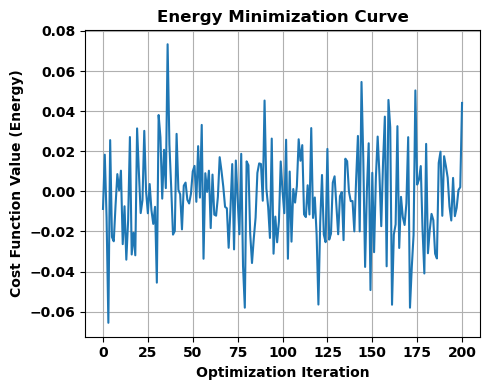

In [29]:
from qxct.circuits import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)
# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    
